<a href="https://colab.research.google.com/github/Samiksha22911/AIML-LAB-EXPERIMENTS/blob/main/K_Nearest_Neighbors_(KNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Experiment 4: K-Nearest Neighbors (KNN)
Dataset: Pima Indians Diabetes dataset (real-world, 150-row sample)

- Implements a KNN classifier
- Chooses the best 'k' using cross-validation
- Evaluates performance and visualizes decision boundaries (2D projection)
"""

"\nExperiment 4: K-Nearest Neighbors (KNN)\nDataset: Pima Indians Diabetes dataset (real-world, 150-row sample)\n\n- Implements a KNN classifier\n- Chooses the best 'k' using cross-validation\n- Evaluates performance and visualizes decision boundaries (2D projection)\n"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)


In [3]:
# 1. Load dataset

df = pd.read_csv("dataset_diabetes.csv")
print("Dataset shape:", df.shape)
print(df["Outcome"].value_counts())  # 0 = no diabetes, 1 = diabetes

X = df.drop(columns=["Outcome"])
y = df["Outcome"].values


Dataset shape: (150, 9)
Outcome
0    97
1    53
Name: count, dtype: int64


In [4]:
# 2. Train/test split + scaling (KNN is distance-based -> scaling matters)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
# 3. Choose best k via cross-validation

k_values = range(1, 21)
cv_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

best_k = k_values[int(np.argmax(cv_scores))]
print(f"\nBest k found via 5-fold CV: {best_k} (CV accuracy = {max(cv_scores):.3f})")

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), cv_scores, marker="o")
plt.axvline(best_k, color="crimson", linestyle="--", label=f"best k = {best_k}")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Cross-validated Accuracy")
plt.title("KNN: Choosing k via Cross-Validation")
plt.legend()
plt.tight_layout()
plt.savefig("k_selection.png", dpi=150)
plt.close()



Best k found via 5-fold CV: 4 (CV accuracy = 0.775)


In [6]:
# 4. Train final model with best k

model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(f"\nAccuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.3f}")

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Diabetes", "Diabetes"]).plot(cmap="Purples")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.close()



Accuracy:  0.733
Precision: 0.714
Recall:    0.455
F1-score:  0.556



Saved plots -> k_selection.png, confusion_matrix.png, decision_boundary.png


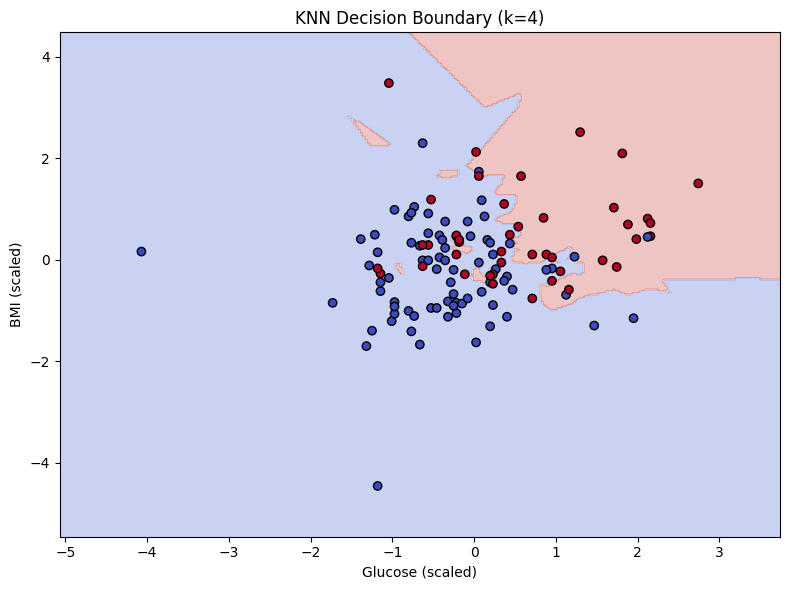

In [7]:
# 5. Visualize decision boundary using 2 key features

feat_x, feat_y = "Glucose", "BMI"
X2 = df[[feat_x, feat_y]].values
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)
scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)

model2 = KNeighborsClassifier(n_neighbors=best_k)
model2.fit(X2_train_s, y2_train)

x_min, x_max = X2_train_s[:, 0].min() - 1, X2_train_s[:, 0].max() + 1
y_min, y_max = X2_train_s[:, 1].min() - 1, X2_train_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = model2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X2_train_s[:, 0], X2_train_s[:, 1], c=y2_train, cmap="coolwarm", edgecolor="k")
plt.xlabel(f"{feat_x} (scaled)")
plt.ylabel(f"{feat_y} (scaled)")
plt.title(f"KNN Decision Boundary (k={best_k})")
plt.tight_layout()
plt.savefig("decision_boundary.png", dpi=150)
print("\nSaved plots -> k_selection.png, confusion_matrix.png, decision_boundary.png")
plt.show()
